In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [2]:
df = pd.read_csv("C:/Users/Admin/Desktop/SentimentAnalysis/dataset/IMDB_Dataset.csv")

In [3]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
df.shape

(50000, 2)

In [5]:
df.columns

Index(['review', 'sentiment'], dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 781.4 KB


In [7]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(418)

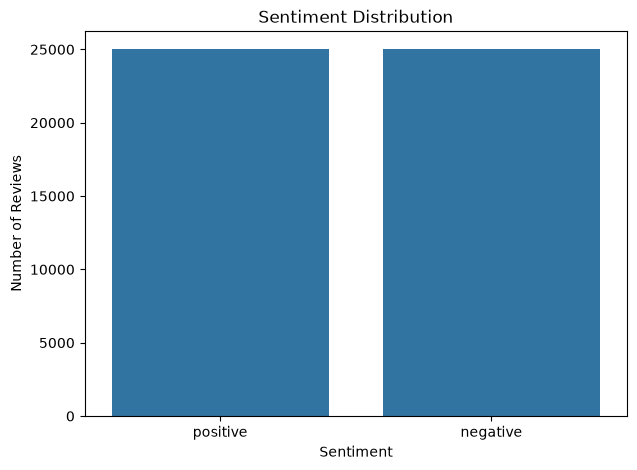

In [9]:
plt.figure(figsize=(7, 5))

sns.countplot(x='sentiment', data=df)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

In [10]:
df = df.drop_duplicates()

In [11]:
df['review_length'] = df['review'].apply(len)

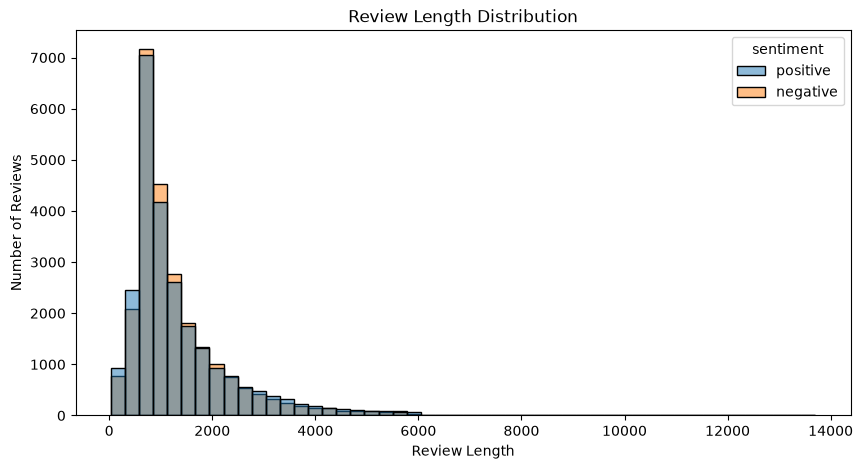

In [12]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x='review_length',
    hue='sentiment',
    bins=50
)

plt.title("Review Length Distribution")
plt.xlabel("Review Length")
plt.ylabel("Number of Reviews")

plt.show()

In [13]:
df['sentiment'] = df['sentiment'].map({
    'positive': 1,
    'negative': 0
})

In [14]:
df.head()

,review,sentiment,review_length
0,One of the other reviewers has mentioned that ...,1,1761
1,A wonderful little production. <br /><br />The...,1,998
2,I thought this was a wonderful way to spend ti...,1,926
3,Basically there's a family where a little boy ...,0,748
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,1317


In [15]:
df['sentiment'].value_counts()

sentiment
1    24884
0    24698
Name: count, dtype: int64

In [16]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return ' '.join(words)

In [17]:
sample = df['review'].iloc[0]

print("Before:")
print(sample)

print("\nAfter:")
print(clean_text(sample))

Before:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to

In [18]:
df['cleaned_review'] = df['review'].apply(clean_text)

In [19]:
df[['review', 'cleaned_review', 'sentiment']].head()

,review,cleaned_review,sentiment
0,One of the other reviewers has mentioned that ...,one reviewers mentioned watching oz episode yo...,1
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...,1
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...,1
3,Basically there's a family where a little boy ...,basically theres family little boy jake thinks...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love time money visually stunni...,1


In [20]:
x = df['cleaned_review']
y = df['sentiment']

In [21]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.20,random_state=42,stratify=y)

In [22]:
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2)
)

In [23]:
x_train_tfidf = tfidf.fit_transform(x_train)

In [24]:
x_test_tfidf = tfidf.transform(x_test)

In [25]:
model = LogisticRegression(
    max_iter=1000
)

In [26]:
model.fit(x_train_tfidf, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [27]:
y_pred = model.predict(x_test_tfidf)

In [28]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy percentage:", accuracy * 100, "%")

Accuracy: 0.8971463144095997
Accuracy percentage: 89.71463144095996 %


In [29]:
print(classification_report(
    y_test,
    y_pred,
    target_names=['Negative', 'Positive']
))

              precision    recall  f1-score   support

    Negative       0.91      0.88      0.90      4940
    Positive       0.89      0.91      0.90      4977

    accuracy                           0.90      9917
   macro avg       0.90      0.90      0.90      9917
weighted avg       0.90      0.90      0.90      9917



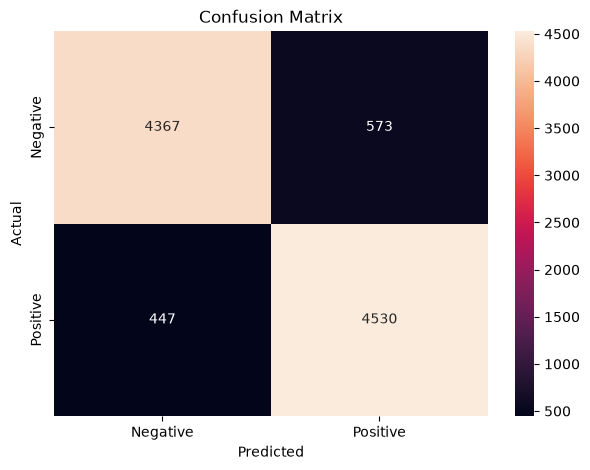

In [30]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [31]:
def predict_sentiment(review):
    
    # Clean the review
    cleaned = clean_text(review)
    
    # Convert to TF-IDF
    review_tfidf = tfidf.transform([cleaned])
    
    # Prediction
    prediction = model.predict(review_tfidf)[0]
    
    # Probability
    probability = model.predict_proba(review_tfidf)[0]
    
    if prediction == 1:
        sentiment = "Positive"
        confidence = probability[1]
    else:
        sentiment = "Negative"
        confidence = probability[0]
    
    print("Review:", review)
    print("Sentiment:", sentiment)
    print("Confidence:", round(confidence * 100, 2), "%")

In [32]:
predict_sentiment("This movie was absolutely amazing!")

Review: This movie was absolutely amazing!
Sentiment: Positive
Confidence: 82.66 %


In [33]:
predict_sentiment("This movie was absolutely fantastic. I loved every moment of it.")

Review: This movie was absolutely fantastic. I loved every moment of it.
Sentiment: Positive
Confidence: 90.21 %


In [34]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

In [35]:
nb_model = MultinomialNB()

nb_model.fit(x_train_tfidf, y_train)

nb_pred = nb_model.predict(x_test_tfidf)

nb_accuracy = accuracy_score(y_test, nb_pred)

print("Naive Bayes Accuracy:", nb_accuracy)
print("Naive Bayes Accuracy Percentage:", nb_accuracy * 100, "%")

Naive Bayes Accuracy: 0.8798023595845518
Naive Bayes Accuracy Percentage: 87.98023595845518 %


In [36]:
svm_model = LinearSVC()

svm_model.fit(x_train_tfidf, y_train)

svm_pred = svm_model.predict(x_test_tfidf)

svm_accuracy = accuracy_score(y_test, svm_pred)

print("Linear SVM Accuracy:", svm_accuracy)
print("Linear SVM Accuracy Percentage:", svm_accuracy * 100, "%")

Linear SVM Accuracy: 0.8991630533427448
Linear SVM Accuracy Percentage: 89.91630533427448 %


In [37]:
lr_accuracy = accuracy_score(y_test, y_pred)

print("Model Comparison")
print("----------------------------")
print("Logistic Regression:", lr_accuracy * 100, "%")
print("Naive Bayes:", nb_accuracy * 100, "%")
print("Linear SVM:", svm_accuracy * 100, "%")

Model Comparison
----------------------------
Logistic Regression: 89.71463144095996 %
Naive Bayes: 87.98023595845518 %
Linear SVM: 89.91630533427448 %


In [38]:
lr_accuracy = accuracy_score(y_test, y_pred)

print("Model Comparison")
print("----------------------------")
print("Logistic Regression:", lr_accuracy * 100, "%")
print("Naive Bayes:", nb_accuracy * 100, "%")
print("Linear SVM:", svm_accuracy * 100, "%")

Model Comparison
----------------------------
Logistic Regression: 89.71463144095996 %
Naive Bayes: 87.98023595845518 %
Linear SVM: 89.91630533427448 %


In [40]:
from sklearn.metrics import f1_score

lr_f1 = f1_score(y_test, y_pred)
nb_f1 = f1_score(y_test, nb_pred)
svm_f1 = f1_score(y_test, svm_pred)

print("F1 Score Comparison")
print("----------------------------")
print("Logistic Regression:", lr_f1)
print("Naive Bayes:", nb_f1)
print("Linear SVM:", svm_f1)

F1 Score Comparison
----------------------------
Logistic Regression: 0.8988095238095238
Naive Bayes: 0.8810141744859253
Linear SVM: 0.9000599640215871


In [41]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Naive Bayes',
        'Linear SVM'
    ],
    'Accuracy': [
        lr_accuracy,
        nb_accuracy,
        svm_accuracy
    ],
    'F1 Score': [
        lr_f1,
        nb_f1,
        svm_f1
    ]
})


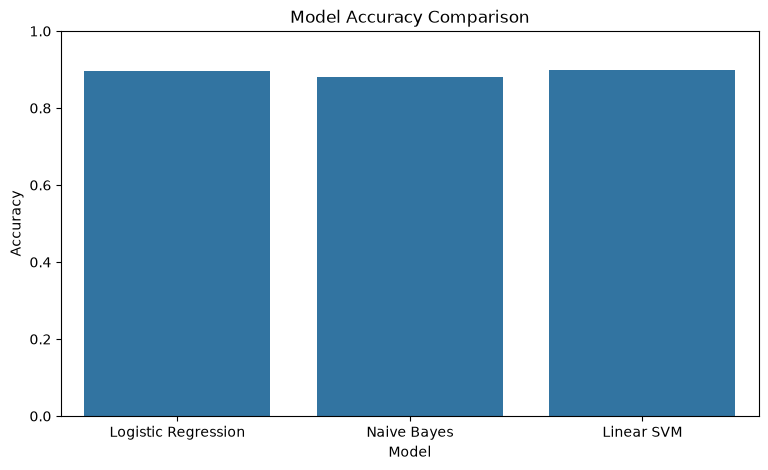

In [42]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=results,
    x='Model',
    y='Accuracy'
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Model")

plt.ylim(0, 1)

plt.show()

In [43]:
from sklearn.metrics import f1_score

lr_f1 = f1_score(y_test, y_pred)
nb_f1 = f1_score(y_test, nb_pred)
svm_f1 = f1_score(y_test, svm_pred)

print("Logistic Regression F1:", lr_f1)
print("Naive Bayes F1:", nb_f1)
print("Linear SVM F1:", svm_f1)


Logistic Regression F1: 0.8988095238095238
Naive Bayes F1: 0.8810141744859253
Linear SVM F1: 0.9000599640215871


In [44]:
import joblib

joblib.dump(svm_model, "sentiment_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!


In [45]:
import os

print("Model exists:", os.path.exists("sentiment_model.pkl"))
print("Vectorizer exists:", os.path.exists("tfidf_vectorizer.pkl"))

Model exists: True
Vectorizer exists: True


In [46]:
def predict_sentiment_svm(review):
    
    cleaned_review = clean_text(review)
    
    review_tfidf = tfidf.transform([cleaned_review])
    
    prediction = svm_model.predict(review_tfidf)[0]
    
    if prediction == 1:
        sentiment = "Positive"
    else:
        sentiment = "Negative"
    
    print("Review:", review)
    print("Sentiment:", sentiment)

In [47]:
predict_sentiment_svm(
    "This movie was absolutely fantastic. I loved every moment of it."
)

Review: This movie was absolutely fantastic. I loved every moment of it.
Sentiment: Positive
